<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week2_Bibit_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Instalation

In [112]:
!pip install Sastrawi -q
!pip install emoji -q
!pip install autocorrect -q

# nlp-id: Kumparan's Indonesian NLP library
!pip install nlp-id -q

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('Installation complete.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 10.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.34.4 which is incompatible.
Installation complete.


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import urllib.request
import emoji
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# nlp-id: Indonesian NLP by Kumparan
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.stopword import StopWord

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from autocorrect import Speller

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


Data Loading & Initial Cleaning

In [118]:
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']
df_review = df_review.drop(columns=cols_to_drop)

print(f'Dropped: {cols_to_drop}')
print(f'Remaining: {df_review.columns.tolist()}')

df_review.head(3)

Dropped: ['reviewId', 'userName', 'userImage', 'appVersion']
Remaining: ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,baik,5,0,3.106.1,2026-03-30 05:08:53,Terima kasih Kak Imam telah memilih Bibit seba...,2026-03-30 06:09:03
1,okelah buat nabung,5,0,3.106.2,2026-03-30 01:40:09,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:07
2,Apk rekomendasi untuk pemula yang ingin tau te...,5,0,3.106.2,2026-03-30 01:38:55,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:03


Remove Duplicate Review

In [119]:
rows_before = len(df_review)
df_review = df_review.drop_duplicates(subset='content', keep='first')

print(f'Duplicates removed: {rows_before - len(df_review):,} | Remaining: {len(df_review):,}')

df_review.head(3)

Duplicates removed: 11,289 | Remaining: 37,769


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,baik,5,0,3.106.1,2026-03-30 05:08:53,Terima kasih Kak Imam telah memilih Bibit seba...,2026-03-30 06:09:03
1,okelah buat nabung,5,0,3.106.2,2026-03-30 01:40:09,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:07
2,Apk rekomendasi untuk pemula yang ingin tau te...,5,0,3.106.2,2026-03-30 01:38:55,Terima kasih telah memilih Bibit sebagai platf...,2026-03-30 01:54:03


LowerCasing

In [120]:
df_review['cleaned'] = df_review['content'].astype(str).str.lower()

df_review[['content', 'cleaned']].head(3)

,content,cleaned
0,baik,baik
1,okelah buat nabung,okelah buat nabung
2,Apk rekomendasi untuk pemula yang ingin tau te...,apk rekomendasi untuk pemula yang ingin tau te...


Indonesia Slang Normalization

In [121]:
URL_KAMUS_ALAY = 'https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv'

try:
    path_file, _ = urllib.request.urlretrieve(URL_KAMUS_ALAY, 'slang_indonesia.csv')
    df_slang = pd.read_csv(path_file)

    slang_map = dict(zip(df_slang['slang'].str.lower(), df_slang['formal'].str.lower()))

    print(f'Kamus alay berhasil dimuat: {len(slang_map):,} entri')
    print('Contoh isi kamus:')
    for slang, formal in list(slang_map.items())[:8]:
        print(f'  {slang:<12} => {formal}')

except Exception as err:
    print(f'Gagal mengunduh ({err}), menggunakan daftar manual.')
    slang_map = {
        'yg': 'yang', 'gk': 'tidak', 'gak': 'tidak', 'nggak': 'tidak',
        'udah': 'sudah', 'udh': 'sudah', 'sdh': 'sudah', 'blm': 'belum',
        'tp': 'tapi', 'jg': 'juga', 'aja': 'saja', 'kyk': 'kayak',
        'utk': 'untuk', 'dgn': 'dengan', 'krn': 'karena', 'bgt': 'banget',
        'gw': 'saya', 'sy': 'saya', 'lu': 'kamu', 'lo': 'kamu',
        'apk': 'aplikasi', 'apps': 'aplikasi', 'ga': 'tidak'
    }
    print(f'Kamus fallback siap: {len(slang_map)} entri')

Kamus alay berhasil dimuat: 4,331 entri
Contoh isi kamus:
  woww         => wow
  aminn        => amin
  met          => selamat
  netaas       => menetas
  keberpa      => keberapa
  eeeehhhh     => eh
  kata2nyaaa   => kata-katanya
  hallo        => halo


In [122]:
def fix_slang(text):
    words = str(text).split()
    return ' '.join([slang_map.get(w, w) for w in words])

df_review['cleaned'] = df_review['cleaned'].apply(fix_slang)

is_changed = df_review['content'].astype(str).str.lower() != df_review['cleaned']
total_affected = is_changed.sum()

print(f'Total baris yang berubah setelah normalisasi: {total_affected:,}')

df_review[is_changed][['content', 'cleaned']].head(5)

Total baris yang berubah setelah normalisasi: 17,289


,content,cleaned
5,manager investasinya bodo nitip duit malah min...,manager investasinya bodo nitip duit malah min...
7,"gak bisaa di bukaa, knpaa yaa?","enggak bisa di bukaa, knpaa yaa?"
10,penarikan uang nya lama bnget,penarikan uang nya lama banget
12,masuk ny lama males ake bibit lagi,masuk nya lama malas ake bibit lagi
14,barusan mau pake ini app tp gak bisa verifikas...,barusan mau pakai ini app tapi enggak bisa ver...


Text Cleaning

In [123]:
def scrub_data(txt):
    txt = re.sub(r'https?://\S+|www\.\S+', '', str(txt))
    txt = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', txt)
    txt = emoji.replace_emoji(txt, replace='')
    txt = re.sub(r'\d+', '', txt)
    txt = re.sub(r'[^\w\s]', '', txt)
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

df_review['cleaned'] = df_review['cleaned'].apply(scrub_data)

df_review[['content', 'cleaned']].sample(5, random_state=42)

,content,cleaned
23859,"Terimakasih PT bibit tumbuh bersama,saya harap...",terimakasih pt bibit tumbuh bersamasaya harap ...
21576,"Aplikasinya memang bagus simple,..cumaaannn wa...",aplikasinya memang bagus simplecumaaannn waktu...
46484,Maen aman aja,main aman saja
9479,Kasih 5 biar lebih akurat serba mudah dengan a...,kasih biar lebih akurat serba mudah dengan apl...
24059,Semoga ada metode pembayaran shopeepay atau dana,semoga ada metode pembayaran shopeepay atau dana


Tokenization

In [125]:
nltk.download('punkt')

df_review['tokens'] = df_review['cleaned'].apply(word_tokenize)
df_review['token_count'] = df_review['tokens'].apply(len)

total_tokens = df_review['token_count'].sum()
avg_tokens = df_review['token_count'].mean()

print(f'Total seluruh token: {total_tokens:,}')
print(f'Rata-rata token per ulasan: {avg_tokens:.2f}')

df_review[['cleaned', 'tokens', 'token_count']].head(5)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Total seluruh token: 452,655
Rata-rata token per ulasan: 11.98


,cleaned,tokens,token_count
0,baik,[baik],1
1,okelah buat nabung,"[okelah, buat, nabung]",3
2,apk rekomendasi untuk pemula yang ingin tau te...,"[apk, rekomendasi, untuk, pemula, yang, ingin,...",10
3,good,[good],1
5,manager investasinya bodo nitip duit malah min...,"[manager, investasinya, bodo, nitip, duit, mal...",35


Stopword Removal

In [130]:
nltk.download('stopwords')

try:
    list_nltk = set(stopwords.words('indonesian'))
    print(f'NLTK (ID) Source: {len(list_nltk)} words')
except:
    list_nltk = set()
    print('NLTK source not found.')

list_sastrawi = set(StopWordRemoverFactory().get_stop_words())
print(f'Sastrawi Source : {len(list_sastrawi)} words')

bibit_context_words = {
    'bibit', 'investasi', 'reksadana',
    'aplikasi', 'app', 'nya', 'apk', 'sih',
    'deh', 'loh', 'nih', 'lah', 'kok',
    'yah', 'wah', 'tuh', 'gitu', 'gini',
    'kak', 'admin', 'cs'
}

stopword_final = list_nltk.union(list_sastrawi).union(bibit_context_words)

print(f'Custom Context  : {len(bibit_context_words)} words')
print(f'Final Combined  : {len(stopword_final)} words')

NLTK (ID) Source: 757 words
Sastrawi Source : 123 words
Custom Context  : 21 words
Final Combined  : 792 words


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [131]:
def filter_stopwords(token_list):
    return [word for word in token_list if word not in stopword_final and len(word) > 1]

df_review['tokens_no_sw'] = df_review['tokens'].apply(filter_stopwords)

total_before = df_review['tokens'].apply(len).sum()
total_after = df_review['tokens_no_sw'].apply(len).sum()

diff = total_before - total_after
pct_diff = (diff / total_before) * 100

print(f'Total token awal : {total_before:,}')
print(f'Total token akhir: {total_after:,}')
print(f'Token terbuang   : {diff:,} ({pct_diff:.1f}%)')

df_review[['tokens', 'tokens_no_sw']].head(5)

Total token awal : 452,655
Total token akhir: 227,140
Token terbuang   : 225,515 (49.8%)


,tokens,tokens_no_sw
0,[baik],[]
1,"[okelah, buat, nabung]","[okelah, nabung]"
2,"[apk, rekomendasi, untuk, pemula, yang, ingin,...","[rekomendasi, pemula, tau, dunia]"
3,[good],[good]
5,"[manager, investasinya, bodo, nitip, duit, mal...","[manager, investasinya, bodo, nitip, duit, min..."


Lemmatization

In [132]:
base_lemmatizer = Lemmatizer()

sample_words = ['berinvestasi', 'keuangan', 'terpercaya', 'menabung', 'pendaftaran']

print('Validasi Lemmatization:')
for word in sample_words:
    root_word = base_lemmatizer.lemmatize(word)
    print(f'  {word:<15} => {root_word}')

Validasi Lemmatization:
  berinvestasi    => investasi
  keuangan        => uang
  terpercaya      => terpercaya
  menabung        => tabung
  pendaftaran     => daftar


In [133]:
def process_lemmatization(token_list):
    if not token_list:
        return []

    sentence_string = ' '.join(token_list)
    lemmatized_string = base_lemmatizer.lemmatize(sentence_string)
    return lemmatized_string.split()

df_review['tokens_lemma'] = df_review['tokens_no_sw'].apply(process_lemmatization)

all_before = [word for sublist in df_review['tokens_no_sw'] for word in sublist]
all_after = [word for sublist in df_review['tokens_lemma'] for word in sublist]

total_lemmatized = sum(1 for a, b in zip(all_before, all_after) if a != b)

print(f'Jumlah token yang berubah setelah lemmatization: {total_lemmatized:,}')

df_review[['tokens_no_sw', 'tokens_lemma']].head(5)

Jumlah token yang berubah setelah lemmatization: 217,007


,tokens_no_sw,tokens_lemma
0,[],[]
1,"[okelah, nabung]","[oke, nabung]"
2,"[rekomendasi, pemula, tau, dunia]","[rekomendasi, mula, tau, dunia]"
3,[good],[good]
5,"[manager, investasinya, bodo, nitip, duit, min...","[manager, investasi, bodo, nitip, duit, minus,..."


Stemming

In [135]:
factory = StemmerFactory()
engine_stemmer = factory.create_stemmer()

def apply_stemming(token_list):
    return [engine_stemmer.stem(word) for word in token_list]

df_review['tokens_stemmed'] = df_review['tokens_lemma'].apply(apply_stemming)

print('Proses stemming pada tokens_lemma telah selesai.')

df_review[['tokens_lemma', 'tokens_stemmed']].head(5)

KeyboardInterrupt: 

Rare Words Removal

In [137]:
THRESHOLD_MIN = 2

semua_kata_lemma = [kata for sublist in df_review['tokens_lemma'] for kata in sublist]
hitung_frekuensi = Counter(semua_kata_lemma)

kata_langka = {k for k, v in hitung_frekuensi.items() if v <= THRESHOLD_MIN}

total_kata_unik = len(hitung_frekuensi)
total_kata_langka = len(kata_langka)
persentase_langka = (total_kata_langka / total_kata_unik) * 100

print(f'Total kosakata unik (lemma) : {total_kata_unik:,}')
print(f'Kata langka (frekuensi <= {THRESHOLD_MIN}): {total_kata_langka:,} ({persentase_langka:.1f}%)')
print(f'Contoh kata yang dihapus    : {list(kata_langka)[:15]}')

df_review['tokens_final'] = df_review['tokens_lemma'].apply(
    lambda tokens: [w for w in tokens if w not in kata_langka]
)

awal_token = df_review['tokens_lemma'].apply(len).sum()
akhir_token = df_review['tokens_final'].apply(len).sum()

print(f'\nTotal token yang dibersihkan : {awal_token - akhir_token:,}')
print(f'Sisa token untuk analisis    : {akhir_token:,}')

df_review[['tokens_lemma', 'tokens_final']].head(5)

Total kosakata unik (lemma) : 23,005
Kata langka (frekuensi <= 2): 19,079 (82.9%)
Contoh kata yang dihapus    : ['innvestid', 'mendem', 'booster', 'mantoppppp', 'zhlcpqq', 'menangin', 'ngewd', 'semtara', 'bvytlh', 'ngejawab', 'hampit', 'mzocd', 'pu', 'oposialnya', 'iniitung']

Total token yang dibersihkan : 21,064
Sisa token untuk analisis    : 206,087


,tokens_lemma,tokens_final
0,[],[]
1,"[oke, nabung]","[oke, nabung]"
2,"[rekomendasi, mula, tau, dunia]","[rekomendasi, mula, tau, dunia]"
3,[good],[good]
5,"[manager, investasi, bodo, nitip, duit, minus,...","[manager, investasi, bodo, nitip, duit, minus,..."


Validation Text

In [138]:
df_review['final_text'] = df_review['tokens_final'].apply(lambda tokens: ' '.join(tokens))

total_kosong = (df_review['final_text'].str.strip() == '').sum()
print(f'Baris kosong setelah pipeline: {total_kosong:,}')

df_review = df_review[df_review['final_text'].str.strip() != '']
print(f'Jumlah baris akhir: {len(df_review):,}')

df_review[['content', 'final_text']].head(5)

Baris kosong setelah pipeline: 1,532
Jumlah baris akhir: 36,237


,content,final_text
1,okelah buat nabung,oke nabung
2,Apk rekomendasi untuk pemula yang ingin tau te...,rekomendasi mula tau dunia
3,good,good
5,manager investasinya bodo nitip duit malah min...,manager investasi bodo nitip duit minus gue ma...
6,Aplikasinya bagus banget,aplikasi bagus banget


In [139]:
print('Perbandingan Sampel (Original -> Final)\n')

sampel_data = df_review[['content', 'final_text']].sample(5, random_state=42)

for _, baris in sampel_data.iterrows():
    print(f'  ASLI  : {baris["content"][:85]}...')
    print(f'  HASIL : {baris["final_text"][:85]}...')
    print('-' * 20)

Perbandingan Sampel (Original -> Final)

  ASLI  : Bibit memiliki fitur yang sangat membantu saya sebagai pemula yang awam dengan reksad...
  HASIL : milik fitur bantu mula awam terima kasih...
--------------------
  ASLI  : Aplikasi terpercaya untuk investasi di masa depan.....
  HASIL : terpercaya...
--------------------
  ASLI  : Wow lama kali wd nya , udah untung jual, lah di itung" Jadi rugi, kena fee terus. Gak...
  HASIL : wow kali wd untung jual itung rugi kena fee rekom dah...
--------------------
  ASLI  : investasi yang mudah dan terpercaya.....
  HASIL : mudah terpercaya...
--------------------
  ASLI  : min mau coba ubah data bank, mau. diganti gimana ya caranya...
  HASIL : min coba ubah data bank ganti...
--------------------


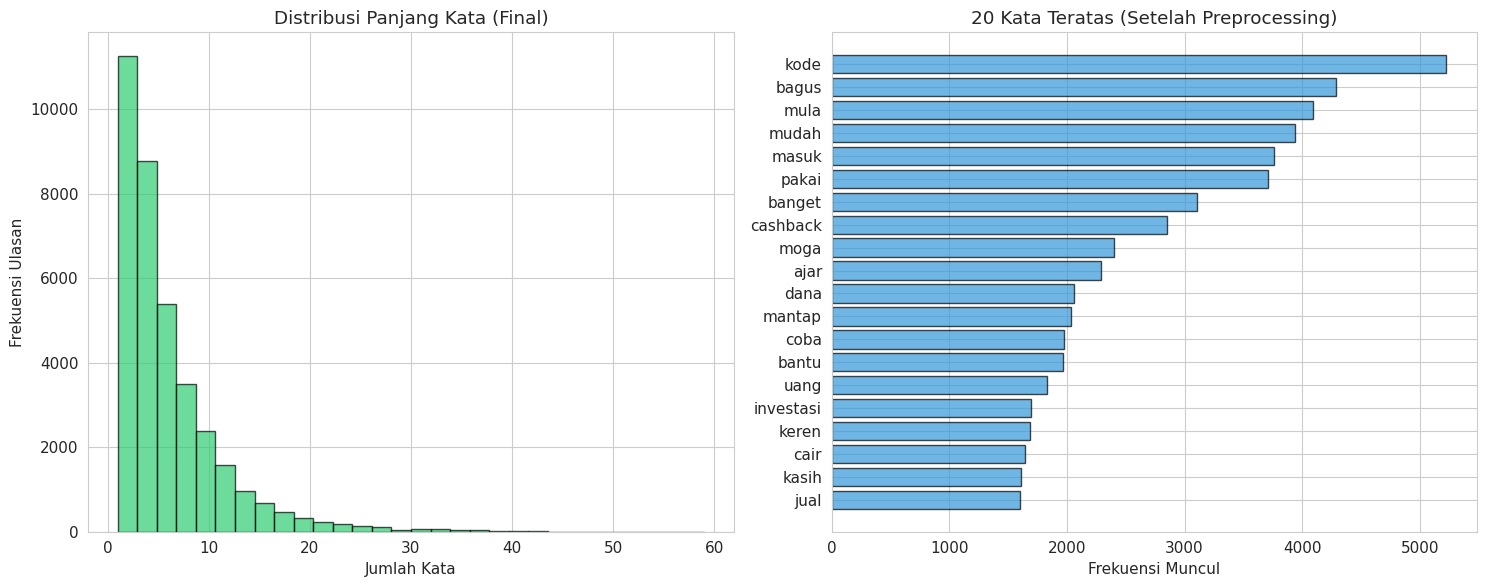

In [140]:
df_review['final_word_count'] = df_review['final_text'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df_review['final_word_count'], bins=30, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribusi Panjang Kata (Final)')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi Ulasan')

semua_kata = ' '.join(df_review['final_text']).split()
kata_top, hitung_top = zip(*Counter(semua_kata).most_common(20))

axes[1].barh(range(len(kata_top)), hitung_top, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(kata_top)))
axes[1].set_yticklabels(kata_top)
axes[1].invert_yaxis()
axes[1].set_title('20 Kata Teratas (Setelah Preprocessing)')
axes[1].set_xlabel('Frekuensi Muncul')

plt.tight_layout()
plt.show()

In [142]:
existing_cols = [col for col in [
    'content', 'score', 'at', 'thumbsUpCount',
    'replyContent', 'final_text', 'tokens_final'
] if col in df_review.columns]

df_clean = df_review[existing_cols].copy()
df_clean.to_csv('bibit_reviews_cleaned.csv', index=False)

print(f'Data berhasil disimpan: bibit_reviews_cleaned.csv')
print(f'Dimensi data: {df_clean.shape[0]:,} baris x {df_clean.shape[1]} kolom')
print(f'Kolom yang disimpan: {existing_cols}')

df_clean.head(5)

Data berhasil disimpan: bibit_reviews_cleaned.csv
Dimensi data: 36,237 baris x 7 kolom
Kolom yang disimpan: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'final_text', 'tokens_final']


,content,score,at,thumbsUpCount,replyContent,final_text,tokens_final
1,okelah buat nabung,5,2026-03-30 01:40:09,0,Terima kasih telah memilih Bibit sebagai platf...,oke nabung,"[oke, nabung]"
2,Apk rekomendasi untuk pemula yang ingin tau te...,5,2026-03-30 01:38:55,0,Terima kasih telah memilih Bibit sebagai platf...,rekomendasi mula tau dunia,"[rekomendasi, mula, tau, dunia]"
3,good,5,2026-03-29 17:29:32,0,Terima kasih telah memilih Bibit sebagai platf...,good,[good]
5,manager investasinya bodo nitip duit malah min...,1,2026-03-29 12:43:12,0,"Hai kak, fluktuasi pasar itu wajar dalam inves...",manager investasi bodo nitip duit minus gue ma...,"[manager, investasi, bodo, nitip, duit, minus,..."
6,Aplikasinya bagus banget,4,2026-03-29 12:41:25,0,Terima kasih atas kepercayaan & kesetiaan kaka...,aplikasi bagus banget,"[aplikasi, bagus, banget]"
